In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs('/content/drive/MyDrive/CAPSTONE_DATA/outputs', exist_ok=True)
print(" Ready!")

Mounted at /content/drive
 Ready!


In [9]:
yt = pd.read_csv('/content/drive/MyDrive/CAPSTONE_DATA/outputs/youtube_comments_with_sentiment.csv')
tw = pd.read_csv('/content/drive/MyDrive/CAPSTONE_DATA/outputs/twitter_influencer_with_sentiment.csv')
reddit = pd.read_csv('/content/drive/MyDrive/CAPSTONE_DATA/outputs/reddit_with_sentiment.csv')

print(f"YouTube: {yt.shape}")
print(f"Twitter: {tw.shape}")
print(f"Reddit: {reddit.shape}")

YouTube: (27299, 11)
Twitter: (239, 19)
Reddit: (1397, 11)


In [10]:
# Load videos to get channel mapping
yt_videos = pd.read_csv('/content/drive/MyDrive/CAPSTONE_DATA/youtube/final_youtube_videos_clean.csv')
yt_channels = pd.read_csv('/content/drive/MyDrive/CAPSTONE_DATA/youtube/final_youtube_channels_clean.csv')

# Merge comments with videos to get channel_id
yt = yt.merge(yt_videos[['video_id', 'channel_id']], on='video_id', how='left')

# Merge with channels to get influencer name
yt = yt.merge(yt_channels[['channel_id', 'name']], on='channel_id', how='left')
yt = yt.rename(columns={'name': 'influencer_name'})

# Aggregate per influencer
yt_agg = yt.groupby('influencer_name').agg(
    youtube_compound=('compound', 'mean'),
    youtube_positive_ratio=('sentiment', lambda x: (x == 'positive').mean()),
    youtube_comment_count=('compound', 'count')
).reset_index()

print(f" YouTube aggregated: {yt_agg.shape}")
print(yt_agg.head())

 YouTube aggregated: (134, 4)
                influencer_name  youtube_compound  youtube_positive_ratio  \
0     Sanjay fitness motivation          0.855500                1.000000   
1               ABHINAV MAHAJAN          0.177168                0.487685   
2          ATMIK YOGA & FITNESS          0.802438                0.875000   
3                Abhishek Yadav          0.488407                0.733333   
4  Achint Chawla - Sneaker Soul          0.250259                0.547826   

   youtube_comment_count  
0                      5  
1                    203  
2                      8  
3                    750  
4                    230  


In [12]:
tw_agg = tw.groupby('influencer_name').agg(
    twitter_compound=('compound', 'mean'),
    twitter_positive_ratio=('sentiment', lambda x: (x == 'positive').mean()),
    twitter_tweet_count=('compound', 'count')
).reset_index()

print(f" Twitter aggregated: {tw_agg.shape}")
print(tw_agg.head())

 Twitter aggregated: (17, 4)
   influencer_name  twitter_compound  twitter_positive_ratio  \
0  Anmol Chaudhary         -0.296000                0.000000   
1       BullyJuice          0.143558                0.263158   
2  Caroline Girvan          0.227605                0.526316   
3   Cheer Shopping          0.093067                0.166667   
4   Cricket Galaxy         -0.042286                0.000000   

   twitter_tweet_count  
0                    1  
1                   19  
2                   19  
3                   18  
4                    7  


In [13]:
reddit_agg = reddit.groupby('influencer_name').agg(
    reddit_compound=('compound', 'mean'),
    reddit_positive_ratio=('sentiment', lambda x: (x == 'positive').mean()),
    reddit_post_count=('compound', 'count')
).reset_index()

print(f" Reddit aggregated: {reddit_agg.shape}")
print(reddit_agg.head())

 Reddit aggregated: (173, 4)
                influencer_name  reddit_compound  reddit_positive_ratio  \
0               ABHINAV MAHAJAN         0.006100               0.300000   
1          ATMIK YOGA & FITNESS         0.651787               0.875000   
2                Abhishek Yadav         0.273500               0.666667   
3  Achint Chawla - Sneaker Soul         0.194633               0.333333   
4           Afton Fitness India        -0.056840               0.600000   

   reddit_post_count  
0                 10  
1                  8  
2                  3  
3                  9  
4                  5  


In [14]:
# Merge on influencer_name
combined = yt_agg.merge(tw_agg, on='influencer_name', how='outer')
combined = combined.merge(reddit_agg, on='influencer_name', how='outer')

# Overall sentiment score (average across platforms)
combined['overall_sentiment'] = combined[['youtube_compound', 'twitter_compound', 'reddit_compound']].mean(axis=1)

print(f" Combined shape: {combined.shape}")
print(combined.head(10))

 Combined shape: (209, 11)
                influencer_name  youtube_compound  youtube_positive_ratio  \
0     Sanjay fitness motivation          0.855500                1.000000   
1               ABHINAV MAHAJAN          0.177168                0.487685   
2          ATMIK YOGA & FITNESS          0.802438                0.875000   
3                Abhishek Yadav          0.488407                0.733333   
4  Achint Chawla - Sneaker Soul          0.250259                0.547826   
5           Afton Fitness India               NaN                     NaN   
6              Alastair Running          0.426584                0.715847   
7       Ali Bhai (shoes review)          0.140357                0.318182   
8               Allen Choudhary               NaN                     NaN   
9            Anita yoga fitness               NaN                     NaN   

   youtube_comment_count  twitter_compound  twitter_positive_ratio  \
0                    5.0               NaN             

In [15]:
print("=== Platform Coverage ===")
print(f"Influencers on YouTube only: {combined['twitter_compound'].isna().sum()}")
print(f"Influencers on Twitter only: {combined['youtube_compound'].isna().sum()}")
print(f"Influencers on all platforms: {combined.dropna(subset=['youtube_compound','twitter_compound','reddit_compound']).shape[0]}")
print(f"\nTotal unique influencers: {combined.shape[0]}")

=== Platform Coverage ===
Influencers on YouTube only: 192
Influencers on Twitter only: 75
Influencers on all platforms: 7

Total unique influencers: 209


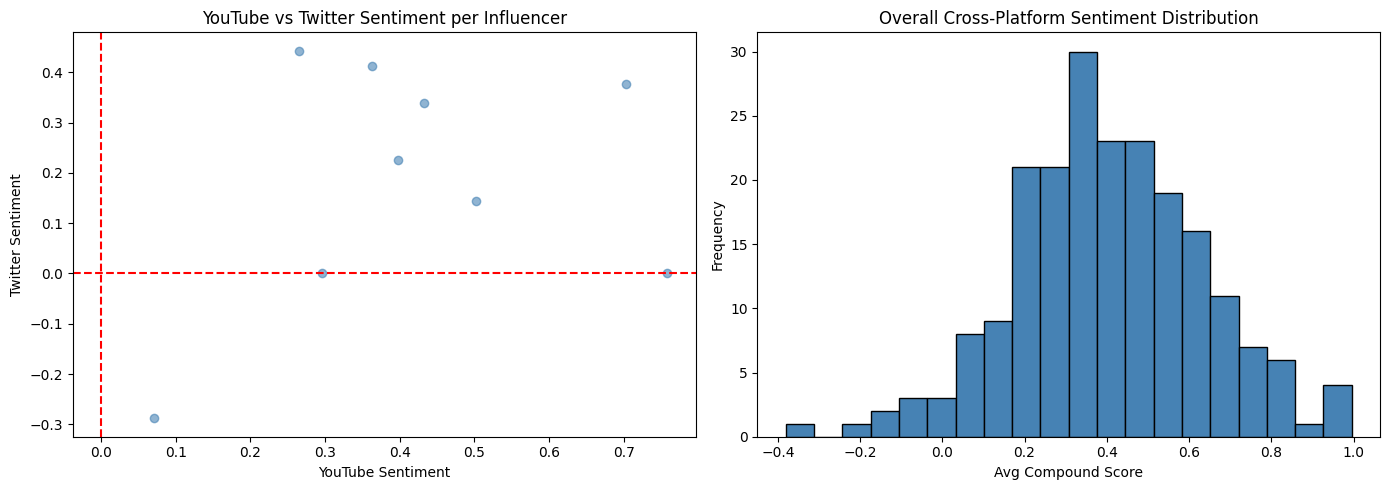

 Plot saved!


In [16]:
# Only influencers present on both YouTube and Twitter
both = combined.dropna(subset=['youtube_compound', 'twitter_compound'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1 - YouTube vs Twitter compound scores
axes[0].scatter(both['youtube_compound'], both['twitter_compound'],
                alpha=0.6, color='steelblue')
axes[0].set_xlabel('YouTube Sentiment')
axes[0].set_ylabel('Twitter Sentiment')
axes[0].set_title('YouTube vs Twitter Sentiment per Influencer')
axes[0].axhline(y=0, color='red', linestyle='--')
axes[0].axvline(x=0, color='red', linestyle='--')

# Plot 2 - Overall sentiment distribution
combined['overall_sentiment'].dropna().plot(kind='hist', bins=20,
    ax=axes[1], color='steelblue', edgecolor='black')
axes[1].set_title('Overall Cross-Platform Sentiment Distribution')
axes[1].set_xlabel('Avg Compound Score')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/CAPSTONE_DATA/outputs/combined_sentiment_plot.png')
plt.show()
print(" Plot saved!")

In [17]:
print("=== Top 10 Most Positive Influencers (Overall) ===")
print(combined[['influencer_name', 'overall_sentiment']].sort_values(
    'overall_sentiment', ascending=False).head(10).to_string(index=False))

print("\n=== Top 10 Most Negative Influencers (Overall) ===")
print(combined[['influencer_name', 'overall_sentiment']].sort_values(
    'overall_sentiment', ascending=True).head(10).to_string(index=False))

=== Top 10 Most Positive Influencers (Overall) ===
                 influencer_name  overall_sentiment
              Anita yoga fitness           0.995522
       Indian Fitness Motivation           0.979150
           Indian 🇮🇳 fitness 555           0.964010
              Yoga Fitness Mania           0.953950
           akshay Indian fitness           0.880390
       Sanjay fitness motivation           0.855500
The virtual dance & yoga fitness           0.829037
              Running Shoes Guru           0.817111
                   yoga fitness            0.805074
             Anita yoga fitness            0.795946

=== Top 10 Most Negative Influencers (Overall) ===
                                   influencer_name  overall_sentiment
                                   Allen Choudhary          -0.380814
                               Jatin Calisthenics           -0.213817
                                   Anmol Chaudhary          -0.124921
                                     Sports B

In [19]:
combined.to_csv(
    '/content/drive/MyDrive/CAPSTONE_DATA/outputs/master_sentiment_scores.csv',
    index=False
)
print(f" Master sentiment file saved!")
print(f"Shape: {combined.shape}")
print(f"\nColumns: {list(combined.columns)}")

 Master sentiment file saved!
Shape: (209, 11)

Columns: ['influencer_name', 'youtube_compound', 'youtube_positive_ratio', 'youtube_comment_count', 'twitter_compound', 'twitter_positive_ratio', 'twitter_tweet_count', 'reddit_compound', 'reddit_positive_ratio', 'reddit_post_count', 'overall_sentiment']
